# 🧬 CDK4 Inhibitor Design Pipeline

This unified notebook provides an end-to-end workflow for designing **CDK4-selective inhibitors** while avoiding **CDK11** binding.

## Pipeline Overview

1. **NIM Service Check** - Verify MolMIM and Boltz2 availability
2. **Seed Definition** - Specify starting molecules
3. **Molecule Generation** - Generate novel candidates with MolMIM
4. **Affinity Prediction** - Predict CDK4/CDK11 binding with Boltz2
5. **Physicochemical Analysis** - Calculate drug-likeness properties
6. **Composite Scoring** - Rank compounds by multi-objective score
7. **Visualization & Report** - Generate results and plots

---

## 1. Setup & Configuration

In [1]:
import sys
from pathlib import Path

# Add cdk_oracle to path
PROJECT_ROOT = Path(".").resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import pipeline components
from cdk_oracle import (
    CDKConfig,
    NIMHealthChecker,
    MolMIMClient,
    Boltz2AffinityClient,
    PhysicochemCalculator,
    CDKScorer,
    CDKVisualizer,
    CDKDesignPipeline
)

print("✓ CDK Oracle package loaded")
print(f"✓ Project root: {PROJECT_ROOT}")

✓ CDK Oracle package loaded
✓ Project root: /home/nilkanthp/documents/nims/openhackathon_github/Bootcamp-BioNemo


In [ ]:
# Initialize configuration
# You can modify these settings directly or via environment variables

config = CDKConfig(
    # NIM URLs - single endpoint (boltz2_url is just the default/primary)
    molmim_url="http://localhost:8005",
    boltz2_url="http://localhost:8000",  # Primary Boltz2 endpoint
    
    # Optimization parameters
    cma_iterations=4,      # Number of CMA-ES iterations
    cma_popsize=10,         # Population size per seed
    cma_sigma=1.0,          # CMA-ES step size
    
    # Scoring weights (must sum to 1.0)
    weights={
        "binding_affinity": 0.25,   # CDK4 binding potency
        "selectivity": 0.20,        # CDK11/CDK4 ratio
        "cdk11_avoidance": 0.15,    # Penalty for CDK11 binding
        "qed": 0.15,                # Drug-likeness
        "sa": 0.10,                 # Synthetic accessibility
        "pains": 0.10,              # PAINS filter
        "novelty": 0.05             # Structural novelty
    },
    
    # Output settings - timestamped folder created automatically!
    # Each run saves to: output/run_YYYYMMDD_HHMMSS/
    # To use a fixed folder: output_dir=Path("./my_output"),
    output_base=Path("./output"),  # Base folder for timestamped runs
    top_n_compounds=20,
)

# === Multiple Boltz2 Endpoints (define OUTSIDE CDKConfig) ===
# This is a LIST of dicts passed to CDKDesignPipeline, NOT to CDKConfig
BOLTZ2_ENDPOINTS = [
    {"url": "http://localhost:8000"},   # Endpoint 1
    {"url": "http://10.125.213.46:8000"},   # Endpoint 2
]

# For single endpoint mode, set:
# BOLTZ2_ENDPOINTS = None

print("Configuration:")
print(f"  On-target: {config.on_target}")
print(f"  Anti-target: {config.anti_target}")
print(f"  CMA iterations: {config.cma_iterations}")
print(f"  Population size: {config.cma_popsize}")
print(f"  Boltz2 endpoints: {len(BOLTZ2_ENDPOINTS) if BOLTZ2_ENDPOINTS else 1}")
print(f"  Output folder: {config.output_dir}")

Configuration:
  On-target: CDK4
  Anti-target: CDK11
  CMA iterations: 4
  Population size: 10
  Boltz2 endpoints: 2


## 2. NIM Service Health Check

In [3]:
# Check NIM services availability
health_checker = NIMHealthChecker(config)
service_status = health_checker.print_status()

# Store availability flags
MOLMIM_AVAILABLE = service_status.get("molmim", False)
BOLTZ2_AVAILABLE = service_status.get("boltz2", False)

if not BOLTZ2_AVAILABLE:
    print("\n⚠️  Boltz2 not available - affinity predictions will fail")
    print("   Start Boltz2 NIM or set BOLTZ2_URL to a running instance")

if not MOLMIM_AVAILABLE:
    print("\n⚠️  MolMIM not available - molecule generation will fail")
    print("   Start MolMIM NIM or set MOLMIM_URL to a running instance")

NIM Service Health Check
✓ MolMIM
    URL: http://localhost:8005
    Status: Service is healthy
✓ Boltz2
    URL: http://localhost:8000
    Status: Service is healthy


## 3. Define Seed Molecules

Start with known CDK4 inhibitors or your own designs.

In [4]:
# Define seed molecules for optimization
# These are CORRECT SMILES for FDA-approved CDK4/6 inhibitors

SEED_MOLECULES = [
    # Palbociclib (Ibrance) - FDA-approved CDK4/6 inhibitor
    # CHEMBL189963, C24H29N7O2, MW=447.5
    "CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n(C5CCCC5)c1=O",
    
    # Ribociclib (Kisqali) - FDA-approved CDK4/6 inhibitor
    # CHEMBL3545110, correct SMILES from ChEMBL database
    "CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n1C1CCCC1",
    
    # Abemaciclib (Verzenio) - FDA-approved CDK4/6 inhibitor
    # CHEMBL3301610, C27H32F2N8, MW=506.6
    "CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1",
]

print(f"Defined {len(SEED_MOLECULES)} seed molecules:")
for i, smi in enumerate(SEED_MOLECULES):
    print(f"  {i+1}. {smi[:60]}...")

Defined 3 seed molecules:
  1. CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n(C5CCCC5)c1=O...
  2. CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n1C1CCCC1...
  3. CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2...


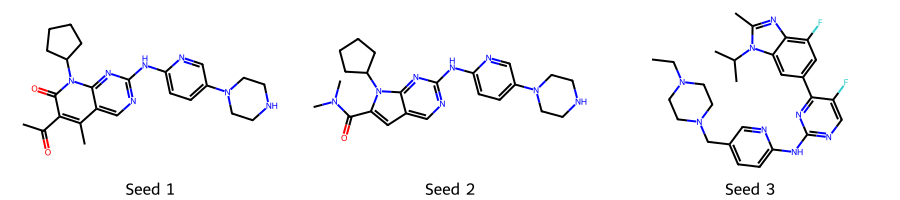

In [5]:
# Visualize seed molecules (optional)
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(smi) for smi in SEED_MOLECULES]
legends = [f"Seed {i+1}" for i in range(len(mols))]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 200), legends=legends)
display(img)

## 4. Run Design Pipeline

Execute the complete workflow with **CDK-aware optimization loop**:

### Optimization Loop (per iteration)
```
┌─────────────────────────────────────────────────────────────────────┐
│  CMA-ES generates 20 candidates                                     │
│                          ↓                                          │
│  FAST FILTER (all 20):                                             │
│    • Validity check                                                │
│    • QED (drug-likeness)                                           │
│    • SA score (synthetic accessibility)                            │
│    • PAINS filter                                                  │
│    • Novelty vs reference                                          │
│                          ↓                                          │
│  SELECT TOP-K (e.g., 10) by fast score                             │
│                          ↓                                          │
│  BOLTZ2 PREDICTIONS (top 10 only):                                 │
│    • CDK4 binding affinity (IC50)                                  │
│    • CDK11 binding affinity (IC50)                                 │
│    • Calculate selectivity ratio                                   │
│                          ↓                                          │
│  COMPOSITE SCORE = weighted sum of:                                │
│    binding + selectivity + avoidance + qed + sa + pains + novelty  │
│                          ↓                                          │
│  FEEDBACK TO CMA-ES (guides next iteration)                        │
└─────────────────────────────────────────────────────────────────────┘
```

This hybrid approach:
- **Saves time**: Only top candidates get expensive Boltz2 calls
- **Maintains quality**: Full CDK scoring guides optimization
- **Tracks progress**: Best compounds saved throughout loop

In [6]:
# Initialize pipeline with optional multi-endpoint Boltz2 for parallel predictions
# If BOLTZ2_ENDPOINTS is set (above), predictions run in parallel across all endpoints
pipeline = CDKDesignPipeline(config, boltz2_endpoints=BOLTZ2_ENDPOINTS)

# Run the complete pipeline with CDK-aware optimization
# 
# Per iteration:
#   1. Generate popsize (20) candidates via CMA-ES
#   2. Fast filter all 20 on: validity, QED, SA, PAINS, novelty
#   3. Select top_k_for_boltz2 (10) for expensive Boltz2 predictions
#   4. Predict CDK4 & CDK11 affinities for top-K (parallel if multiple endpoints!)
#   5. Compute full composite score (affinity + selectivity + drug-likeness)
#   6. Feed scores back to CMA-ES for next iteration
#
# After all iterations: final batch Boltz2 scoring on all unique valid molecules

results = pipeline.run(
    seed_smiles=SEED_MOLECULES,
    num_iterations=config.cma_iterations,  # 10 iterations per seed
    popsize=config.cma_popsize,            # 20 candidates per iteration
    top_k_for_boltz2=5,                   # Top 10 get Boltz2 predictions per iteration
    use_cma=True,                          # Use CMA-ES optimization
    use_msa=True,                          # Use MSA for Boltz2 (better accuracy)
    reference_smiles=SEED_MOLECULES,       # For novelty scoring
    verbose=True,
    generate_report=True
)

⚡ Multi-endpoint mode: 2 Boltz2 endpoints configured
   Endpoint 1: http://localhost:8000
   Endpoint 2: http://10.125.213.46:8000
CDK Inhibitor Design Pipeline
On-target: CDK4
Anti-target: CDK11
Generating molecules from 3 seeds...
  Iterations: 4
  Population size: 10
  Top-K for Boltz2: 5
  Using MSA: True

Optimizing from seed 1/3
  Seed: CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n(C5CCCC5)c1=O...
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 512 (seed=495846, Wed Jan 14 11:31:03 2026)

  Iteration 1/4
Loading ChEMBL fingerprints from /home/nilkanthp/documents/nims/openhackathon_github/Bootcamp-BioNemo/scoring/chembl_data/chembl_fingerprints.pkl...
Loaded 2474589 ChEMBL fingerprints
    Valid molecules: 10/10
    Running Boltz2 on top 5 candidates...
      CC(=O)N1CCCc2c1nc(-c1ccc(C3CCNCC3)cn1)n2... CDK4=31.0nM, sel=7.4x
      CC(=O)c1cc(-c2cnn(C)c2)c(N2CCNCC2)cc1Cl... CDK4=113.9nM, sel=0.4x
      CC(=O)c1cc(C(=O)Nc2cccc(CN3CCNC3=O)c2C)c... CDK4=25.2nM, sel=5.7x
      CC(=O)c1cc(

KeyboardInterrupt: 

  [6/59] C[C@H](CC(=O)NCc1ccnc(-c2ccccc... done
  [3/59] CC[C@H](C)[C@H](Cn1c(-c2cccnc2... done
  [9/59] O=S(=O)(NCc1cc2cnccc2s1)N1C[C@... done
  [5/59] CC(=O)c1c(C)oc2nc(CNc3ccnn3Cc3... done
  [8/59] C[C@H]1CN(C(=O)c2cnccn2)C[C@H]... done
  [11/59] CC(=O)N1CCC[C@@H](NC[C@@H](O)c... done
  [13/59] CC(=O)c1cccc(OCC(=O)Nc2c(C)ccc... done
  [15/59] C=C[C@H](C(=O)N[C@H]1C[C@H](NC... done
  [14/59] CS(=O)(=O)c1cc2cn(C[C@@H]3CCCN... done
  [10/59] C[C@@H]1C[C@@H]1N1C[C@@H](NC(=... done


## 5. View Results

In [ ]:
# Best compounds identified DURING optimization (with in-loop Boltz2 scoring)
# These were the top candidates at each iteration that received full CDK affinity predictions
print("="*80)
print("BEST COMPOUNDS FROM OPTIMIZATION LOOP")
print("(These were scored with Boltz2 during CMA-ES iterations)")
print("="*80)

loop_best = pipeline.get_best_compounds_from_generation(n=15)
if len(loop_best) > 0:
    display(loop_best[[
        "smiles", "cdk4_ic50", "cdk11_ic50", "selectivity", 
        "qed", "total_score", "seed_idx", "iteration"
    ]].head(15))
else:
    print("No in-loop Boltz2 predictions available")

In [ ]:
# Final ranked compounds (after complete batch scoring)
print("="*80)
print("TOP 10 COMPOUNDS (FINAL RANKING)")
print("="*80)

top_10 = results.get_top_compounds(10)
display(top_10[[
    "rank", "compound_id", "cdk4_ic50_nm", "cdk11_ic50_nm", 
    "selectivity_ratio", "qed", "total_score"
]])

In [ ]:
# Summary statistics
print("="*80)
print("PIPELINE SUMMARY")
print("="*80)
for key, value in results.summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.3f}")
    else:
        print(f"  {key}: {value}")

# Optimization loop statistics
print("\nOptimization Loop Summary:")
print(f"  Total Boltz2 calls during loop: {len(pipeline._best_compounds) if hasattr(pipeline, '_best_compounds') else 'N/A'}")
if hasattr(pipeline, '_history') and pipeline._history:
    import numpy as np
    boltz2_calls = sum([h.get('boltz2_count', 0) for h in pipeline._history])
    print(f"  Boltz2 predictions in loop: {boltz2_calls}")
    avg_valid = np.mean([h.get('valid_count', 0) for h in pipeline._history])
    print(f"  Avg valid molecules/iteration: {avg_valid:.1f}")

## 6. Visualizations


In [ ]:
# Affinity scatter plot (CDK4 vs CDK11)
visualizer = CDKVisualizer(config)
visualizer.plot_affinity_scatter(results.scores_df)

In [ ]:
# Score distributions
visualizer.plot_score_distribution(results.scores_df)

In [ ]:
# Top compounds bar chart
visualizer.plot_top_compounds(results.scores_df, n=10)

In [ ]:
# Optimization progress (if CMA-ES was used)
if results.history:
    visualizer.plot_optimization_progress(results.history)

## 7. Save Results

In [ ]:
# Results are AUTO-SAVED by pipeline.run() to a timestamped folder!
# This cell shows what was saved:

print(f"Results saved to: {config.output_dir}")
print("\nFiles automatically generated:")
print("  ✓ all_compounds_scores.csv  (All molecules with full oracle scores)")
print("  ✓ top_compounds.csv         (Top N compounds)")
print("  ✓ run_summary.json          (Pipeline statistics)")
print("  ✓ generated_smiles.txt      (All generated SMILES)")
print("  ✓ seed_molecules.txt        (Input seeds)")
print("  ✓ design_report.html        (Interactive HTML report)")

# Optional: Save additional results manually
# results.save(config.output_dir)

## 8. Export for Submission

In [ ]:
# Create submission file
submission_df = results.get_top_compounds(25)[["smiles", "compound_id"]].copy()
submission_df.to_csv(config.output_dir / "submission.csv", index=False)

print(f"Submission file created: {config.output_dir / 'submission.csv'}")
print(f"Contains {len(submission_df)} compounds")

---

## Alternative: Evaluate Existing Compounds

If you have your own SMILES to evaluate (skip generation):

In [ ]:
# Example: Evaluate custom compounds
# my_compounds = [
#     "CC1=CC=C(C=C1)NC2=NC=NC3=C2C=C(C=C3)F",
#     "CN1CCN(CC1)C2=CC=C(C=C2)NC3=NC=NC4=C3C=CC=C4",
# ]
#
# eval_results = pipeline.evaluate_existing(
#     smiles_list=my_compounds,
#     use_msa=True,
#     verbose=True
# )
# display(eval_results.scores_df)

---

## Quick Reference

### Scoring Weights
| Component | Weight | Description |
|-----------|--------|-------------|
| binding_affinity | 0.25 | CDK4 potency (lower IC50 = better) |
| selectivity | 0.20 | CDK11/CDK4 ratio (higher = better) |
| cdk11_avoidance | 0.15 | Avoiding CDK11 (higher IC50 = better) |
| qed | 0.15 | Drug-likeness (0-1) |
| sa | 0.10 | Synthetic accessibility |
| pains | 0.10 | PAINS-free (binary) |
| novelty | 0.05 | Structural novelty |

### Desirable Properties
- **CDK4 IC50**: < 100 nM (ideally < 10 nM)
- **CDK11 IC50**: > 1,000 nM (ideally > 10,000 nM)
- **Selectivity**: > 10x (ideally > 100x)
- **QED**: > 0.5
- **Lipinski violations**: ≤ 1
- **PAINS alerts**: 0